<a href="https://colab.research.google.com/github/fabriciosantana/mcdia/blob/main/10-adap/assignments/avaliacao_impacto_DEA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instituto Brasileiro de Ensino, Desenvolvimento e Pesquisa**

Programa de Pós-Graduação em Administração Pública — Mestrado Profissional

**Disciplina:** Auditoria de dados e accountability com python

**Professor:** Aloísio Dourado Neto

**Atividade:** Exercício do Módulo III - Análise de desempenho - DEA (Data Envelope Analisys) - Comparação de Indicadores de Desenvolvimento Humano em Regiões

**Grupo:** Analécia Rorato, Fabricio Santana, Giovanni Brígido, Paulo Ceser

## Comparação de Indicadores de Desenvolvimento Humano em Regiões

Este notebook aplica **Análise Envoltória de Dados (DEA)** aos indicadores de desenvolvimento humano do arquivo `dea_desenv_humano.csv`. A atividade compara regiões (DMUs) usando a renda como recurso e expectativa de vida, conhecimento e satisfação como resultados.

> **Nota:** DEA mede eficiência relativa, não identifica sozinho um efeito causal. Assim, aqui “impacto” significa desempenho relativo compatível com melhor conversão de recursos em resultados. Para estimar causalidade seriam necessários contrafactual, grupo de comparação e dimensão temporal, entre outros pressupostos.

### Objetivo e especificação do modelo

O objetivo deste notebook é responder à seguinte pergunta:

> **Quais regiões apresentam as melhores práticas relativas na transformação de renda em resultados de desenvolvimento humano?**

Para responder à pergunta, adota-se a seguinte especificação:

- **DMUs:** regiões identificadas pela variável `dmu`;
- **input:** `Renda`;
- **outputs:** `ExpecVida`, `Conhecimento` e `Satisfacao`;
- **modelo principal:** BCC orientado a outputs, com retornos variáveis de escala;
- **modelo de comparação:** CCR orientado a outputs, com retornos constantes de escala.

A orientação a outputs estima quanto os resultados poderiam aumentar proporcionalmente, mantendo-se a renda observada. O modelo BCC é adotado como principal porque permite que as regiões operem em escalas distintas.

### Configuração

Se necessário, instalar as dependências usadas neste notebook. Caso não exista, criar no mesmo diretório deste notebook um arquivo com nome requirements.txt com as linhas a seguir:
- numpy
- pandas
- matplotlib
- scipy

In [ ]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Além das bibliotecas acima, também é necessário ter a biblioteca adndea. Entretando, o procedimento para obtê-la é diferente.

In [ ]:
!git clone https://gitlab.com/aloisio/adndea.git

Cloning into 'adndea'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 36 (delta 2), reused 0 (delta 0), pack-reused 30 (from 1)
Receiving objects: 100% (36/36), 7.04 KiB | 721.00 KiB/s, done.
Resolving deltas: 100% (15/15), done.


Importar as bibliotecas necessárias

In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import adndea.solver as dea

pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8-whitegrid')


Configurar a origem dos dados

In [ ]:
DATA_FILE = Path('data/dea_desenv_humano.csv')

### Carregamento dos dados

In [ ]:

if DATA_FILE is None:
    raise FileNotFoundError('Arquivo dea_desenv_humano.csv não encontrado. Ajuste a lista candidatos.')

df = pd.read_csv(DATA_FILE)
print(f'Arquivo: {DATA_FILE.resolve()} | dimensão: {df.shape}')
display(df)

Arquivo: /workspaces/mcdia/10-adap/assignments/data/dea_desenv_humano.csv | dimensão: (10, 5)


,dmu,Renda,ExpecVida,Conhecimento,Satisfacao
0,N,11436,56.7,2.0,7.5
1,A1,5122,48.6,1.4,8.0
2,A2,6714,45.8,1.8,7.0
3,A3,950,38.7,0.5,5.0
4,A4,2200,37.0,0.9,4.5
5,A5,500,35.0,0.8,3.5
6,A6,3000,48.5,1.2,6.5
7,A7,4200,52.0,1.7,6.0
8,A8,1780,50.6,1.0,3.0
9,A9,7000,59.0,1.5,9.0


### Análise Exploratória dos Dados

Esta etapa realiza uma análise exploratória dos dados antes da estimação DEA.



#### Qualidade dos dados

Verificamos esquema, tipos, ausências, duplicidades, unicidade das DMUs e positividade. As validações interrompem a execução caso alguma condição indispensável ao modelo não seja atendida.

In [ ]:
variaveis = ['Renda', 'ExpecVida', 'Conhecimento', 'Satisfacao']
esperadas = ['dmu', *variaveis]

# Estrutura e qualidade dos dados
faltantes = set(esperadas) - set(df.columns)
assert not faltantes, f'Colunas ausentes: {faltantes}'
assert df['dmu'].is_unique, 'Cada DMU deve aparecer uma única vez.'
assert not df[esperadas].isna().any().any(), 'Há valores ausentes.'
assert not df.duplicated().any(), 'Há linhas completamente duplicadas.'
assert (df[variaveis] > 0).all().all(), 'DEA requer valores estritamente positivos nesta aplicação.'

qualidade = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'ausentes': df.isna().sum(),
    'ausentes_pct': df.isna().mean().mul(100),
    'valores_unicos': df.nunique(),
})

print(f'Linhas: {len(df)} | Colunas: {df.shape[1]} | '
      f'Duplicatas: {df.duplicated().sum()} | DMUs repetidas: {df.dmu.duplicated().sum()}')
display(qualidade)

Linhas: 10 | Colunas: 5 | Duplicatas: 0 | DMUs repetidas: 0


,tipo,ausentes,ausentes_pct,valores_unicos
dmu,str,0,0.0,10
Renda,int64,0,0.0,10
ExpecVida,float64,0,0.0,10
Conhecimento,float64,0,0.0,10
Satisfacao,float64,0,0.0,10


#### Estatísticas descritivas

Amplitude, coeficiente de variação e assimetria complementam as medidas usuais. O coeficiente de variação compara a dispersão relativa de indicadores medidos em escalas diferentes.

In [ ]:
descritivas = df[variaveis].describe().T
descritivas['amplitude'] = descritivas['max'] - descritivas['min']
descritivas['cv_pct'] = 100 * descritivas['std'] / descritivas['mean']
descritivas['assimetria'] = df[variaveis].skew()
display(descritivas[['count', 'mean', 'std', 'min', '25%', '50%', '75%',
                     'max', 'amplitude', 'cv_pct', 'assimetria']])

,count,mean,std,min,25%,50%,75%,max,amplitude,cv_pct,assimetria
Renda,10.0,4290.20,3380.2945,500.0,1885.000,3600.00,6316.000,11436.0,10936.0,78.7911,1.0097
ExpecVida,10.0,47.19,8.1297,35.0,40.475,48.55,51.650,59.0,24.0,17.2276,-0.2122
Conhecimento,10.0,1.28,0.4826,0.5,0.925,1.30,1.650,2.0,1.5,37.7020,-0.0768
Satisfacao,10.0,6.00,1.9720,3.0,4.625,6.25,7.375,9.0,6.0,32.8671,-0.1358


#### Distribuições e possíveis valores atípicos

Histogramas mostram concentração e assimetria. Os boxplots usam escores-z somente para permitir a comparação visual entre escalas; os dados originais continuam sendo usados no DEA. A regra do intervalo interquartil sinaliza pontos para investigação, não para exclusão automática.

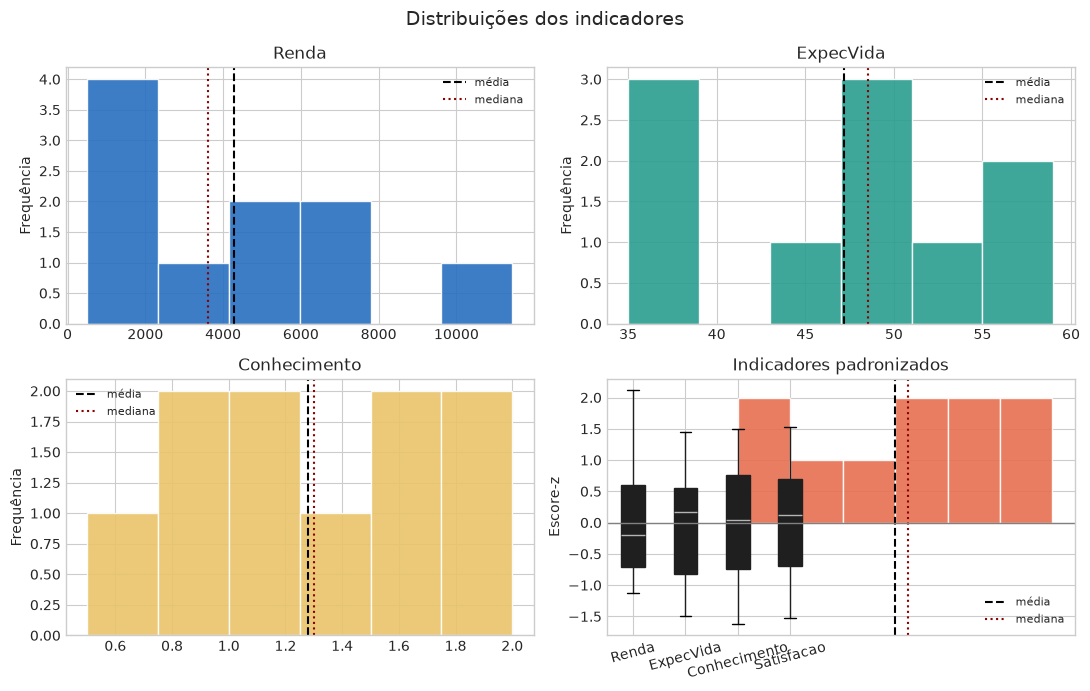

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
cores = ['#276FBF', '#2A9D8F', '#E9C46A', '#E76F51']
for ax, coluna, cor in zip(axes.flat, variaveis, cores):
    ax.hist(df[coluna], bins=min(6, len(df)), color=cor, edgecolor='white', alpha=.9)
    ax.axvline(df[coluna].mean(), color='black', linestyle='--', label='média')
    ax.axvline(df[coluna].median(), color='darkred', linestyle=':', label='mediana')
    ax.set(title=coluna, ylabel='Frequência')
    ax.legend(fontsize=8)
fig.suptitle('Distribuições dos indicadores', fontsize=14)
plt.tight_layout();

padronizado = (df[variaveis] - df[variaveis].mean()) / df[variaveis].std(ddof=1)
ax = padronizado.boxplot(figsize=(10, 4), patch_artist=True)
ax.axhline(0, color='gray', linewidth=1)
ax.set(title='Indicadores padronizados', ylabel='Escore-z')
plt.xticks(rotation=15)
plt.tight_layout();

In [ ]:
q1, q3 = df[variaveis].quantile(.25), df[variaveis].quantile(.75)
iqr = q3 - q1
inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mascara = df[variaveis].lt(inferior) | df[variaveis].gt(superior)
outliers = (df[['dmu']].join(df[variaveis].where(mascara))
            .melt(id_vars='dmu', var_name='variavel', value_name='valor').dropna())
display(outliers if not outliers.empty else
        pd.DataFrame({'diagnostico': ['Nenhum possível outlier pela regra 1,5×IQR']}))

,diagnostico
0,"Nenhum possível outlier pela regra 1,5×IQR"


#### Relações entre os indicadores

A correlação de Pearson resume associações lineares. Os gráficos de dispersão permitem examinar a relação entre renda e cada output, além de identificar as DMUs potencialmente influentes. Correlação não implica causalidade.

,Renda,ExpecVida,Conhecimento,Satisfacao
Renda,1.000,0.740,0.891,0.763
ExpecVida,0.740,1.000,0.742,0.664
Conhecimento,0.891,0.742,1.000,0.683
Satisfacao,0.763,0.664,0.683,1.000


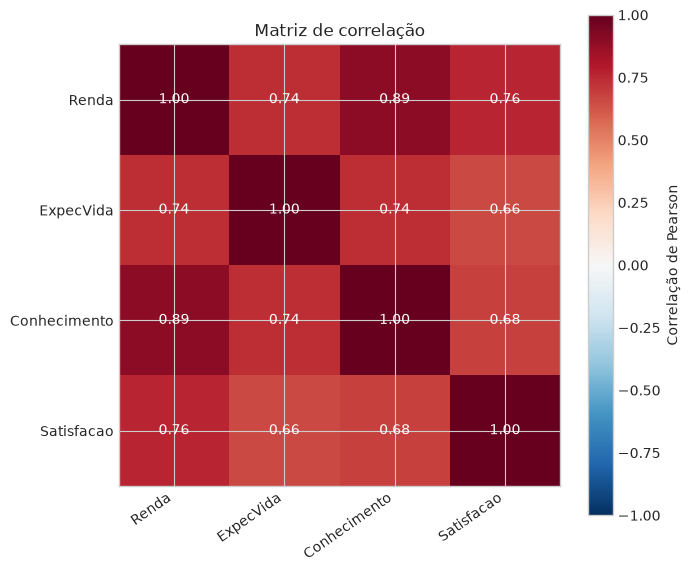

In [ ]:
corr = df[variaveis].corr()
display(corr.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format('{:.3f}'))
fig, ax = plt.subplots(figsize=(7, 6))
imagem = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(variaveis)), variaveis, rotation=35, ha='right')
ax.set_yticks(range(len(variaveis)), variaveis)
for i in range(len(variaveis)):
    for j in range(len(variaveis)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > .55 else 'black')
fig.colorbar(imagem, ax=ax, label='Correlação de Pearson')
ax.set_title('Matriz de correlação')
plt.tight_layout();

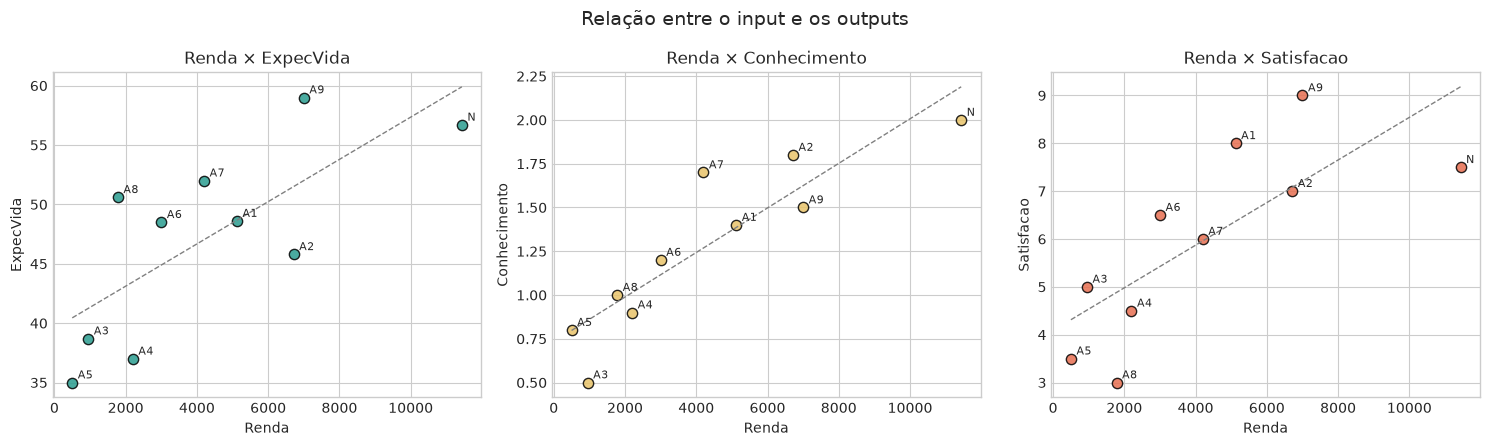

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, saida, cor in zip(axes, ['ExpecVida', 'Conhecimento', 'Satisfacao'], cores[1:]):
    ax.scatter(df['Renda'], df[saida], s=55, color=cor, edgecolor='black', alpha=.85)
    for _, linha in df.iterrows():
        ax.annotate(linha['dmu'], (linha['Renda'], linha[saida]), xytext=(4, 3),
                    textcoords='offset points', fontsize=8)
    coef = np.polyfit(df['Renda'], df[saida], 1)
    grade = np.linspace(df['Renda'].min(), df['Renda'].max(), 100)
    ax.plot(grade, np.polyval(coef, grade), '--', color='gray', linewidth=1)
    ax.set(xlabel='Renda', ylabel=saida, title=f'Renda × {saida}')
fig.suptitle('Relação entre o input e os outputs', fontsize=14)
plt.tight_layout();

#### Perfil relativo das DMUs

O mapa de calor compara cada DMU com a média da amostra. Valores positivos representam indicadores acima da média. Ele ajuda a identificar especializações que podem ser favorecidas pelos pesos flexíveis do DEA.

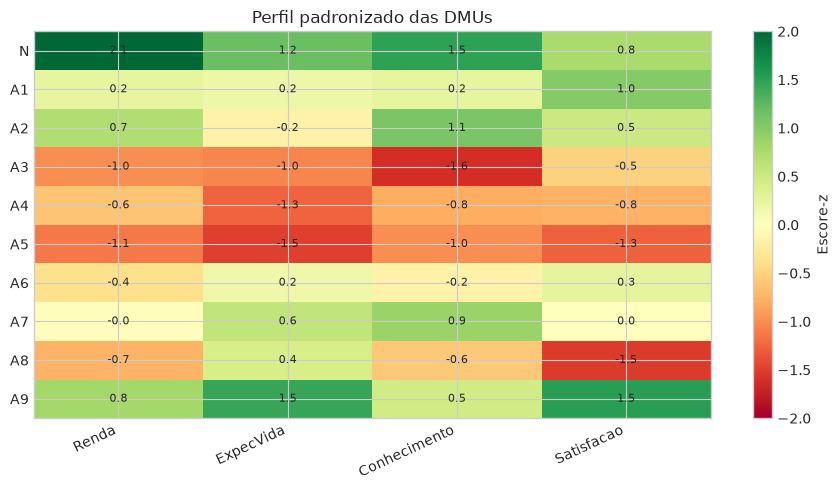

In [ ]:
perfil = padronizado.set_axis(df['dmu'])
fig, ax = plt.subplots(figsize=(9, 5))
imagem = ax.imshow(perfil, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(variaveis)), variaveis, rotation=25, ha='right')
ax.set_yticks(range(len(perfil)), perfil.index)
for i in range(perfil.shape[0]):
    for j in range(perfil.shape[1]):
        ax.text(j, i, f'{perfil.iloc[i, j]:.1f}', ha='center', va='center', fontsize=8)
fig.colorbar(imagem, ax=ax, label='Escore-z')
ax.set_title('Perfil padronizado das DMUs')
plt.tight_layout();

#### Síntese exploratória

A base não apresenta ausências, duplicidades, identificadores repetidos ou valores não positivos. A exploração caracteriza a heterogeneidade, as associações entre renda e resultados e observações potencialmente influentes.

### Adequação e limitações da amostra

Há somente 10 DMUs e quatro variáveis no modelo. Pela regra prática $n \geq \max\{m \times s, 3(m+s)\}$, seriam recomendadas pelo menos 12 DMUs para 1 input e 3 outputs. Portanto, existe risco de muitas unidades aparecerem eficientes e os resultados devem ser tratados como exploratórios. As variáveis também precisam ser comparáveis e pertencer ao mesmo período; o CSV não traz metadados para confirmar essas condições.

### Execução do DEA com a biblioteca `adndea`

O modelo principal é executado por `dea.BCC_O(X, Y)`: BCC indica retornos variáveis de escala e `_O`, orientação a outputs. Como comparação, `dea.CCR_O(X, Y)` estima o modelo com retornos constantes de escala. Cada item retornado contém os pesos calculados pelo modelo e a eficiência relativa da DMU.

In [ ]:
# Métodos DEA disponibilizados pela biblioteca do professor
metodos_disponiveis = ['CCR_O', 'CCR_I', 'BCC_O', 'BCC_I']
print('Métodos disponíveis:', ', '.join(metodos_disponiveis))

Métodos disponíveis: CCR_O, CCR_I, BCC_O, BCC_I


### Estimação do modelo principal e comparação

In [ ]:
inputs = ['Renda']
outputs = ['ExpecVida', 'Conhecimento', 'Satisfacao']
X = df[inputs].to_numpy(float)
Y = df[outputs].to_numpy(float)

# Modelo solicitado: BCC orientado a outputs; CCR_O é usado como comparação
res_bcc = dea.BCC_O(X, Y)
res_ccr = dea.CCR_O(X, Y)

resultado = df.copy()
resultado['ef_bcc'] = [r[1] for r in res_bcc]
resultado['ef_ccr'] = [r[1] for r in res_ccr]
resultado['ef_escala'] = (resultado['ef_ccr'] / resultado['ef_bcc']).clip(upper=1)
resultado['aumento_radial_pct'] = 100 * (1 / resultado['ef_bcc'] - 1)
resultado['status_bcc'] = np.where(resultado['ef_bcc'] >= 1 - 1e-6, 'Eficiente', 'Ineficiente')
display(resultado.sort_values(['ef_bcc', 'dmu'], ascending=[False, True]))

,dmu,Renda,ExpecVida,Conhecimento,Satisfacao,ef_bcc,ef_ccr,ef_escala,aumento_radial_pct,status_bcc
1,A1,5122,48.6,1.4,8.0,1.0000,0.2231,0.2231,0.0000,Eficiente
2,A2,6714,45.8,1.8,7.0,1.0000,0.1676,0.1676,0.0000,Eficiente
3,A3,950,38.7,0.5,5.0,1.0000,0.7519,0.7519,0.0000,Eficiente
5,A5,500,35.0,0.8,3.5,1.0000,1.0000,1.0000,0.0000,Eficiente
6,A6,3000,48.5,1.2,6.5,1.0000,0.3095,0.3095,0.0000,Eficiente
7,A7,4200,52.0,1.7,6.0,1.0000,0.2530,0.2530,0.0000,Eficiente
8,A8,1780,50.6,1.0,3.0,1.0000,0.4061,0.4061,0.0000,Eficiente
9,A9,7000,59.0,1.5,9.0,1.0000,0.1837,0.1837,0.0000,Eficiente
0,N,11436,56.7,2.0,7.5,1.0000,0.1093,0.1093,0.0000,Eficiente
4,A4,2200,37.0,0.9,4.5,0.8327,0.2922,0.3509,20.0884,Ineficiente


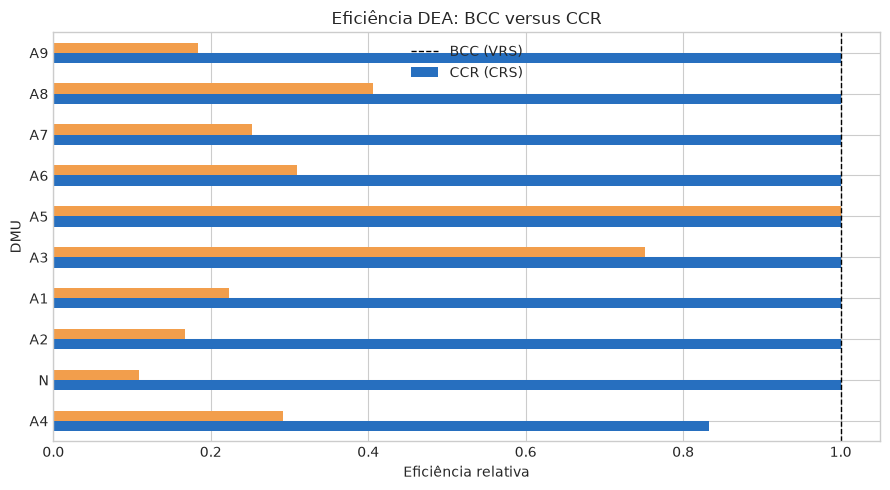

In [ ]:
ax = resultado.sort_values('ef_bcc').plot.barh(
    x='dmu', y=['ef_bcc', 'ef_ccr'], figsize=(9, 5), color=['#276FBF', '#F29E4C']
)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set(xlabel='Eficiência relativa', ylabel='DMU', title='Eficiência DEA: BCC versus CCR')
ax.legend(['BCC (VRS)', 'CCR (CRS)'])
plt.tight_layout();

### DMUs ineficientes e metas radiais

Para uma unidade ineficiente, `aumento_radial_pct` indica a expansão proporcional dos outputs associada ao escore radial. As metas são calculadas multiplicando cada output observado por $1/\text{eficiência}$. Como `adndea.BCC_O` retorna pesos e eficiência, mas não os coeficientes $\lambda$ da forma envelope, estas são metas estritamente radiais: não incorporam folgas nem identificam unidades de referência. Também não são previsões automáticas ou efeitos causais garantidos.

In [ ]:
metas = resultado[['dmu', 'ef_bcc', 'aumento_radial_pct']].copy()
fator_expansao = 1 / resultado['ef_bcc']
for nome in outputs:
    metas[f'{nome}_observado'] = df[nome]
    metas[f'{nome}_meta_radial'] = df[nome] * fator_expansao

display(metas.query('ef_bcc < 1 - 1e-6').sort_values('ef_bcc'))

,dmu,ef_bcc,aumento_radial_pct,ExpecVida_observado,ExpecVida_meta_radial,Conhecimento_observado,Conhecimento_meta_radial,Satisfacao_observado,Satisfacao_meta_radial
4,A4,0.8327,20.0884,37.0,44.4327,0.9,1.0808,4.5,5.404


### Síntese automática dos achados

In [ ]:
eficientes = resultado.loc[resultado['ef_bcc'] >= 1 - 1e-6, 'dmu'].tolist()
ineficientes = resultado.loc[resultado['ef_bcc'] < 1 - 1e-6].sort_values('ef_bcc')
print(f'DMUs eficientes no BCC: {eficientes}')
print(f'Eficiência BCC média: {resultado.ef_bcc.mean():.3f}')
if not ineficientes.empty:
    pior = ineficientes.iloc[0]
    print(f'Maior distância da fronteira: {pior.dmu}, eficiência {pior.ef_bcc:.3f} '          f'e expansão radial potencial de {pior.aumento_radial_pct:.1f}%.')
print(f'Eficiência de escala média: {resultado.ef_escala.mean():.3f}')

DMUs eficientes no BCC: ['N', 'A1', 'A2', 'A3', 'A5', 'A6', 'A7', 'A8', 'A9']
Eficiência BCC média: 0.983
Maior distância da fronteira: A4, eficiência 0.833 e expansão radial potencial de 20.1%.
Eficiência de escala média: 0.376


### Análise de sensibilidade

Com uma amostra pequena e três outputs, os pesos flexíveis podem favorecer especializações. Como teste simples de robustez, reestimamos o BCC retirando um output por vez. Mudanças grandes de classificação indicam que a conclusão depende da escolha dos indicadores.

In [ ]:
sensibilidade = pd.DataFrame({'dmu': df['dmu'], 'modelo_completo': resultado['ef_bcc']})
for removida in outputs:
    cols = [c for c in outputs if c != removida]
    teste = dea.BCC_O(X, df[cols].to_numpy(float))
    sensibilidade[f'sem_{removida}'] = [r[1] for r in teste]

display(sensibilidade.set_index('dmu').style.background_gradient(cmap='RdYlGn', vmin=0, vmax=1))

,modelo_completo,sem_ExpecVida,sem_Conhecimento,sem_Satisfacao
dmu,,,,
N,1.000000,1.000000,0.961020,1.000000
A1,1.000000,1.000000,1.000000,0.889660
A2,1.000000,1.000000,0.792280,0.997660
A3,1.000000,1.000000,1.000000,0.955920
A4,0.832720,0.827260,0.808850,0.776940
A5,1.000000,1.000000,1.000000,1.000000
A6,1.000000,1.000000,1.000000,0.938130
A7,1.000000,1.000000,0.968470,1.000000
A8,1.000000,0.899810,1.000000,1.000000


### Conclusão e recomendações

A fronteira BCC identifica as regiões que, **dentro desta amostra**, combinam renda e resultados de modo relativamente mais favorável. Para as unidades abaixo da fronteira, o escore permite calcular a expansão radial proporcional dos outputs. A diferença entre BCC e CCR revela a parcela associada à escala de operação.

Para que esta análise sustente uma avaliação de impacto de política pública mais forte, recomenda-se: (1) ampliar o número de municípios/regiões; (2) documentar fonte, período, população e deflacionamento da renda; (3) justificar a relação causal entre o recurso e cada resultado; (4) aplicar restrições de pesos ou reduzir outputs quando apropriado; (5) comparar períodos pré e pós-política com Índice de Malmquist; e (6) combinar os escores DEA com um desenho causal, como diferenças-em-diferenças ou RDD, sem tratar o escore DEA isolado como efeito causal.